In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import average_precision_score
import subprocess
from sklearn.metrics.pairwise import cosine_distances
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from collections import defaultdict


In [17]:

def readFormatProbabilitys(adress:str):
    data = pd.read_csv(adress,header=None)

    values = []
    for i,j in data.groupby(1):
        values.append([j[0].values[0],j[1].values[0],j[2].values])

    df = pd.DataFrame(values)
    df = df.rename(columns={0:"leftNode",
                       1:"rightNode",
                       2:"probability"})
    return df

    
def readFormatExcludedlinks(adress:str):

   
    dfExcluded = pd.read_csv(adress,header=None)
    dfExcluded.rename(columns={0:"leftNode",
                               1:"rightNode"},inplace=True)
    dfExcluded["leftNode"] = dfExcluded["leftNode"].astype("int64")
    
    return dfExcluded

In [18]:

def collect_kurt_skew_degrees(ourmethod_dir: str = "/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/rating/OurMethod",
                              train_graph_path: str = "/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/ratingtrainGraph.csv",
                              file_glob: str = "*.csv",
                              reversed= False):
    """
    Read all CSVs in `ourmethod_dir` (matching file_glob), for each row compute:
      - kurtosis and skew of the probability time-series
      - left node degree and right node degree (from train_graph_path, undirected)
    Returns a single DataFrame with columns:
      ['file','leftNode','rightNode','kurt','skew','left_degree','right_degree']
    """
    import os
    import glob

    # load train graph and compute undirected degree map
    tg = pd.read_csv(train_graph_path, header=None)
    if tg.shape[1] >= 2:
        tg = tg.rename(columns={0: "leftNode", 1: "rightNode"})
    else:
        raise ValueError("train_graph must have at least two columns")

    tg["leftNode"] = tg["leftNode"].astype(str).str.strip()
    tg["rightNode"] = tg["rightNode"].astype(str).str.strip()

    if(reversed):
        tg[["rightNode","leftNode"]] = tg[["leftNode","rightNode"]]

    # undirected degree: count occurrences in either column
    all_nodes = pd.concat([tg["leftNode"], tg["rightNode"]])
    degree_counts = all_nodes.value_counts().to_dict()

    files = sorted(glob.glob(os.path.join(ourmethod_dir, file_glob)))
    rows = []
    for idx,f in enumerate(files):
        try:
            dfPI = readFormatProbabilitys(f)
        except Exception:
            continue
        # ensure strings
        dfPI["leftNode"] = dfPI["leftNode"].astype(str).str.strip()
        dfPI["rightNode"] = dfPI["rightNode"].astype(str).str.strip()

        # probabilities -> DataFrame of series (each row corresponds to one candidate)
        pv = pd.DataFrame([i for i in dfPI.probability.values])


        kurts = pv.kurt(axis=1).fillna(0.0)
        skews = pv.skew(axis=1).fillna(0.0)

        for idx, (ln, rn, k, s) in enumerate(zip(dfPI["leftNode"].values, dfPI["rightNode"].values, kurts.values, skews.values)):
            ld = int(degree_counts.get(str(ln), 0))
            rd = int(degree_counts.get(str(rn), 0))
            rows.append({
                "file": os.path.basename(f),
                "leftNode": ln,
                "rightNode": rn,
                "kurt": float(k),
                "skew": float(s),
                "left_degree": ld,
                "right_degree": rd
            })

    out = pd.DataFrame(rows, columns=["file","leftNode","rightNode","kurt","skew","left_degree","right_degree"])
    return out


In [19]:
ourmethod_dir = "/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/fire/direct"
ourmethod_inverted_dir = "/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/fire/inverse"
train_graph_path = "/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/fire/trainGraph.csv"
test_graph_path = "/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/fire/testGraph.csv"
nn_hidden = (50,)
nn_epochs = 200
nn_lr = 1e-3
holdout_blue_frac = 0.5
random_state = 42
verbose = True

rng = np.random.RandomState(random_state)

results = {
    "degrees_only": {},
    "moments_only": {},
    "moments_combined": {}
}
print(1)

# --- carregar features ---
df_base = collect_kurt_skew_degrees(
    ourmethod_dir=ourmethod_dir,
    train_graph_path=train_graph_path,
    reversed=False
)
print(2)

df_inv = collect_kurt_skew_degrees(
    ourmethod_dir=ourmethod_inverted_dir,
    train_graph_path=train_graph_path,
    reversed=True
)
print(3)


1
2
3


In [20]:
if df_base is None or df_base.empty:
    print("Erro: df_base vazio")

# merge base + invertido
df = df_base.copy()
df = df.rename(columns={
    "kurt": "kurt_base",
    "skew": "skew_base"
})

df_inv = df_inv.rename(columns={
    "kurt": "kurt_inv",
    "skew": "skew_inv"
})

df = df.merge(
    df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
    on=["leftNode", "rightNode"],
    how="left"
)
print(df.shape)
# --- labels ---
tmp = df[["leftNode", "rightNode"]].copy()

excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
excl["_is_label"] = 1

tmp = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

oe = pd.read_csv(train_graph_path, header=None)\
    .rename(columns={0:"leftNode",1:"rightNode"}).astype(str)
oe["_is_train"] = 1

tmp = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

df["label"] = tmp["_is_label"].values
df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

# --- splits ---
idx_red = df.index[df["original"] == 1].values
idx_blue = df.index[(df["label"] == 0) & (df["original"] == 0)].values
idx_green = df.index[df["label"] == 1].values

train_blue_idx, holdout_blue_idx = train_test_split(
    idx_blue, test_size=holdout_blue_frac, random_state=random_state
)

test_idx = np.concatenate([idx_green, holdout_blue_idx])
df_test = df.loc[test_idx].reset_index(drop=True)

# --- sampling 1:10 ---
def sample_negatives(pool, n_pos, ratio=10):
    n_neg = ratio * n_pos
    if len(pool) <= n_neg:
        return pool
    return rng.choice(pool, size=n_neg, replace=False)

n_pos = len(idx_red)
sampled_neg = sample_negatives(train_blue_idx, n_pos, ratio=10)
train_idx = np.concatenate([idx_red, sampled_neg])

if df_base is None or df_base.empty:
    print("Erro: df_base vazio")

# merge base + invertido
df = df_base.copy()
df = df.rename(columns={
    "kurt": "kurt_base",
    "skew": "skew_base"
})

df_inv = df_inv.rename(columns={
    "kurt": "kurt_inv",
    "skew": "skew_inv"
})

df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]] = df_inv[["rightNode", "leftNode", "kurt_inv", "skew_inv"]]
df = df.merge(
    df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
    on=["leftNode", "rightNode"],
    how="left"
)
df["lg_left_degree"] = np.log1p(df["left_degree"].fillna(0).astype(float))
df["lg_right_degree"] = np.log1p(df["right_degree"].fillna(0).astype(float))



print(df.shape)
# --- labels ---
tmp = df[["leftNode", "rightNode"]].copy()

excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
excl["_is_label"] = 1

tmp = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

oe = pd.read_csv(train_graph_path, header=None)\
    .rename(columns={0:"leftNode",1:"rightNode"}).astype(str)
oe["_is_train"] = 1

tmp = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

df["label"] = tmp["_is_label"].values


df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

# --- splits ---
idx_red = df.index[df["original"] == 1].values
idx_blue = df.index[(df["label"] == 0) & (df["original"] == 0)].values
idx_green = df.index[df["label"] == 1].values

train_blue_idx, holdout_blue_idx = train_test_split(
    idx_blue, test_size=holdout_blue_frac, random_state=random_state
)

test_idx = np.concatenate([idx_green, holdout_blue_idx])
df_test = df.loc[test_idx].reset_index(drop=True)

# --- sampling 1:10 ---
def sample_negatives(pool, n_pos, ratio=10):
    n_neg = ratio * n_pos
    if len(pool) <= n_neg:
        return pool
    return rng.choice(pool, size=n_neg, replace=False)

n_pos = len(idx_red)
sampled_neg = sample_negatives(train_blue_idx, n_pos, ratio=10)
train_idx = np.concatenate([idx_red, sampled_neg])




(261120, 9)
(261120, 11)


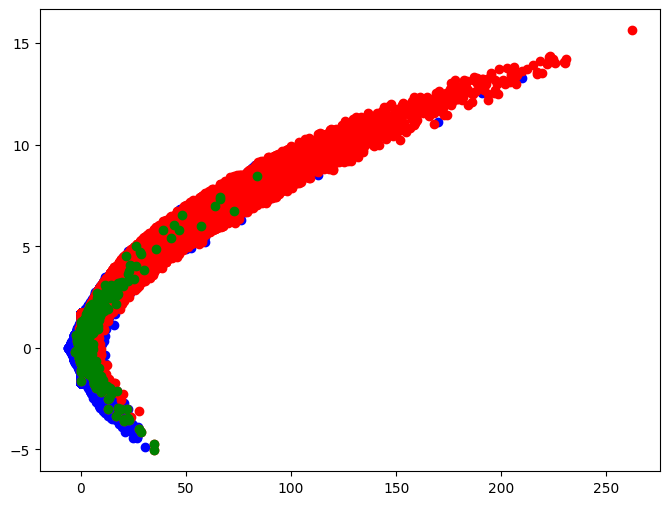

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot()



green = df[df["label"] == 1].copy().drop(columns=["original","label"])
blue = df[(df["label"] == 0) & (df["original"]==0)].copy().drop(columns=["original","label"])
red = df[(df["original"] == 1)].copy().drop(columns=["original","label"])

ax.scatter(x=blue["kurt_inv"],y= blue["skew_inv"],c="blue")
ax.scatter(x=red["kurt_inv"],y= red["skew_inv"],c="red")
ax.scatter(x=green["kurt_inv"],y= green["skew_inv"],c="green")


# plt.scatter(df["kurt_base"].values,df["skew_base"].values)
plt.show()

In [11]:
df["lg_left_degree"] = np.log1p(df["left_degree"].fillna(0).astype(float))
df["lg_right_degree"] = np.log1p(df["right_degree"].fillna(0).astype(float))

df.columns

Index(['file', 'leftNode', 'rightNode', 'kurt_base', 'skew_base',
       'left_degree', 'right_degree', 'kurt_inv', 'skew_inv', 'lg_left_degree',
       'lg_right_degree', 'label', 'original'],
      dtype='object')

In [22]:
# --- modelo ---
import random
nn_hidden = (32,16)
nn_epochs = 200


def bpr_loss(s_pos, s_neg):
    return -torch.mean(torch.log(torch.sigmoid(s_pos - s_neg)))

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.05))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_eval(feat_cols, key):

    X_train = df.loc[train_idx, feat_cols].fillna(0).values
    y_train = df.loc[train_idx, "original"].values

    X_test = df_test[feat_cols].fillna(0).values
    y_test = df_test["label"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = MLP(len(feat_cols), nn_hidden).to(device)
    opt = optim.Adam(model.parameters(), lr=nn_lr)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    for ep in range(1, nn_epochs + 1):
        model.train()
        opt.zero_grad()

        n_pairs = min(len(pos_idx), len(neg_idx))

        pos_sample = np.random.choice(pos_idx, n_pairs, replace=False)
        neg_sample = np.random.choice(neg_idx, n_pairs, replace=False)

        X_pos_t = X_train_t[pos_sample]
        X_neg_t = X_train_t[neg_sample]

        s_pos = model(X_pos_t)
        s_neg = model(X_neg_t)

        loss = bpr_loss(s_pos, s_neg)

        loss.backward()
        opt.step()

        if verbose and (ep % max(1, nn_epochs // 10) == 0 or ep == 1 or ep == nn_epochs):
            with torch.no_grad():
                test_logits = model(X_test_t)
                test_probs = torch.sigmoid(test_logits).cpu().numpy()

                if y_test.size > 0 and len(np.unique(y_test)) > 1:
                    try:
                        aupr_tmp = average_precision_score(y_test, test_probs)
                        auroc_tmp = roc_auc_score(y_test, test_probs)
                    except:
                        aupr_tmp, auroc_tmp = None, None
                else:
                    aupr_tmp, auroc_tmp = None, None
            # print(f"[ep {ep}/{nn_epochs}] loss={loss.item():.6f} AUPR={aupr_tmp} AUROC={auroc_tmp}")
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
    model.train()

    aupr = average_precision_score(y_test, test_probs)
    auroc = roc_auc_score(y_test, test_probs)

    if verbose:
        print(f"{key} -> AUPR: {aupr:.4f}, AUROC: {auroc:.4f}")

    return {
        "aupr": float(aupr),
        "auroc": float(auroc)
    }

    # --- MODELOS ---


def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def run_multiple(train_eval_fn, feat_cols, key, n_runs=3               
                , base_seed=42):
    results = []

    for i in range(n_runs):
        seed = base_seed + i
        set_seed(seed)

        if "verbose" in train_eval_fn.__code__.co_varnames:
            out = train_eval_fn(feat_cols, key, verbose=False)
        else:
            out = train_eval_fn(feat_cols, key)

        # espera formato: results[key] = {"aupr": ..., "auroc": ...}
        if out is not None:
            aupr = out["aupr"]
            auroc = out["auroc"]
        else:
            continue

        if aupr is not None and auroc is not None:
            results.append((aupr, auroc))

    results = np.array(results)

    mean_aupr = results[:, 0].mean()
    std_aupr = results[:, 0].std()

    mean_auroc = results[:, 1].mean()
    std_auroc = results[:, 1].std()

    return {
        "aupr_mean": float(mean_aupr),
        "aupr_std": float(std_aupr),
        "auroc_mean": float(mean_auroc),
        "auroc_std": float(std_auroc)
    }


# 1. degrees only

res = run_multiple(
    train_eval,
        ["left_degree", "right_degree"],
    "degrees_only",
    n_runs=5)


res2 = run_multiple(
train_eval,
    ["kurt_base", "skew_base"],
"moments_only",
n_runs=5
)


# 2. moments only
res3 = run_multiple(
train_eval,
    ["lg_left_degree","lg_right_degree","kurt_base", "skew_base"],
"moments_only+degree",
n_runs=5
)
# 3. moments combined
res4 = run_multiple(
train_eval,
["lg_left_degree", "lg_right_degree","kurt_base", "skew_base", "kurt_inv", "skew_inv"],
"moments_combined",
n_runs=5
)

print(res)
print(res2)
print(res3)
print(res4)


degrees_only -> AUPR: 0.3617, AUROC: 0.8721
degrees_only -> AUPR: 0.3623, AUROC: 0.8690
degrees_only -> AUPR: 0.3609, AUROC: 0.8710
degrees_only -> AUPR: 0.3685, AUROC: 0.8711
degrees_only -> AUPR: 0.3683, AUROC: 0.8716
moments_only -> AUPR: 0.0413, AUROC: 0.4124
moments_only -> AUPR: 0.0421, AUROC: 0.4235
moments_only -> AUPR: 0.0442, AUROC: 0.4498
moments_only -> AUPR: 0.0414, AUROC: 0.4134
moments_only -> AUPR: 0.0421, AUROC: 0.4200
moments_only+degree -> AUPR: 0.2219, AUROC: 0.8384
moments_only+degree -> AUPR: 0.2171, AUROC: 0.8422
moments_only+degree -> AUPR: 0.2135, AUROC: 0.8339
moments_only+degree -> AUPR: 0.2011, AUROC: 0.8407
moments_only+degree -> AUPR: 0.1873, AUROC: 0.8248
moments_combined -> AUPR: 0.2301, AUROC: 0.8446


KeyboardInterrupt: 

In [14]:
pip uninstall sympy -y
pip install sympy==1.12

SyntaxError: invalid syntax (1323811405.py, line 1)